# SEMANA 7 — ANÁLISIS COMPARATIVO DE ALGORITMOS DE CLASIFICACIÓN

## Ejercicio aplicado con Bank Marketing

**Estudiante:** Gabriela Suesca Castillo  
**Universidad:** Universidad de Cundinamarca  
**Asignatura:** Introducción a Machine Learning  
**Docente:** Monica Fonseca  
**Fecha:** 7 de octubre de 2026

**Objetivo:** comparar siete algoritmos de clasificación supervisada sobre el mismo problema y dataset para identificar cuál ofrece el comportamiento más conveniente para predecir si un cliente contratará un depósito a plazo.

**Modelos:** Regresión Logística, k-NN, Árbol de Decisión, Random Forest, SVM, Naive Bayes y Red Neuronal Artificial.

## 1. Planteamiento del problema

La pregunta de análisis es: **¿Cuál de varios algoritmos de clasificación supervisada permite predecir mejor si un cliente aceptará contratar un depósito a plazo después de una campaña de marketing telefónico?**

La variable objetivo es binaria: `no = 0` y `yes = 1`. Todos los modelos se entrenarán con los mismos datos y el mismo particionamiento para que la comparación sea justa.

## 2. Fuente y características de los datos

Se utiliza el conjunto **Bank Marketing** del UCI Machine Learning Repository. La variable objetivo `y` indica si el cliente suscribió o no un depósito a plazo. En el trabajo anterior se observó que la clase positiva es minoritaria, por lo que en esta comparación no se utilizará Accuracy como único criterio.

La variable `duration` se excluye porque representa la duración de la llamada y puede introducir información que solo está disponible después del contacto.

## 3. Instalación y librerías

In [1]:
!pip -q install ucimlrepo

In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Entorno preparado correctamente")

Entorno preparado correctamente


## 4. Carga del dataset

In [3]:
bank_marketing = fetch_ucirepo(id=222)

X_original = bank_marketing.data.features.copy()
y_original = bank_marketing.data.targets.copy()

df = pd.concat([X_original, y_original], axis=1)

print("Datos descargados correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
display(df.head())

Datos descargados correctamente
Filas: 45211
Columnas: 17


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [4]:
print("Columnas:")
print(df.columns.tolist())

print("\nValores faltantes:")
display(df.isnull().sum())

print("Registros duplicados:", df.duplicated().sum())

Columnas:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Valores faltantes:


,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


Registros duplicados: 0


## 5. Distribución de la variable objetivo

In [5]:
tabla_clases = pd.DataFrame({
    "Conteo": df["y"].value_counts(),
    "Porcentaje": (df["y"].value_counts(normalize=True) * 100).round(2)
})
display(tabla_clases)

,Conteo,Porcentaje
y,,
no,39922,88.3
yes,5289,11.7


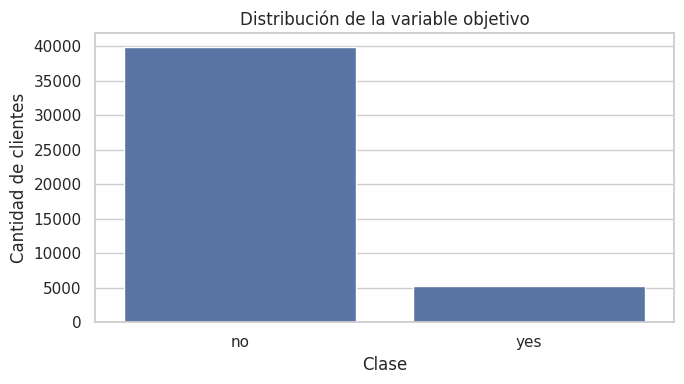

In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="y")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

## 6. Preparación de variables

In [7]:
df["y_bin"] = df["y"].map({"no": 0, "yes": 1})

predictores = [
    "age", "job", "marital", "education", "default",
    "balance", "housing", "loan", "contact", "day_of_week",
    "month", "campaign", "pdays", "previous", "poutcome"
]

X = df[predictores].copy()
y = df["y_bin"].copy()

variables_numericas = [
    "age", "balance", "day_of_week", "campaign", "pdays", "previous"
]

variables_categoricas = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome"
]

print("Predictores:", len(predictores))
print("Variables numéricas:", len(variables_numericas))
print("Variables categóricas:", len(variables_categoricas))

Predictores: 15
Variables numéricas: 6
Variables categóricas: 9


## 7. División entrenamiento / prueba

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("\nProporción de clases en entrenamiento:")
display(y_train.value_counts(normalize=True).rename("Proporcion"))
print("\nProporción de clases en prueba:")
display(y_test.value_counts(normalize=True).rename("Proporcion"))

Entrenamiento: (36168, 15)
Prueba: (9043, 15)

Proporción de clases en entrenamiento:


,Proporcion
y_bin,
0,0.883018
1,0.116982



Proporción de clases en prueba:


,Proporcion
y_bin,
0,0.883003
1,0.116997


## 8. Preprocesamiento

Las variables numéricas se imputan con la mediana y se estandarizan. Las categóricas se imputan con la categoría más frecuente y se transforman con One-Hot Encoding. Se utiliza la misma transformación para todos los modelos.

In [9]:
transformaciones_numericas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformaciones_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", transformaciones_numericas, variables_numericas),
        ("cat", transformaciones_categoricas, variables_categoricas)
    ],
    sparse_threshold=0
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Dimensión de entrenamiento después del preprocesamiento:", X_train_proc.shape)
print("Dimensión de prueba después del preprocesamiento:", X_test_proc.shape)

Dimensión de entrenamiento después del preprocesamiento: (36168, 37)
Dimensión de prueba después del preprocesamiento: (9043, 37)


## 9. Configuración de los siete algoritmos

Los algoritmos corresponden a los modelos trabajados en el material de apoyo. El PDF describe Regresión Logística, k-NN, Árboles de Decisión, Random Forest, SVM, Naive Bayes y Redes Neuronales, junto con sus principales usos, ventajas y limitaciones.

In [10]:
modelos = {
    "Regresión Logística": LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE
    ),
    "k-NN": KNeighborsClassifier(
        n_neighbors=15, weights="distance", n_jobs=-1
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        criterion="gini", max_depth=6, min_samples_leaf=20,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=12, min_samples_leaf=5,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM": SVC(
        kernel="linear", class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Naive Bayes": GaussianNB(),
    "Red Neuronal": MLPClassifier(
        hidden_layer_sizes=(32,), activation="relu", solver="adam",
        alpha=0.001, batch_size=256, learning_rate_init=0.001,
        max_iter=250, early_stopping=True, validation_fraction=0.10,
        random_state=RANDOM_STATE
    )
}

print("Modelos configurados:", len(modelos))

Modelos configurados: 7


## 10. Entrenamiento y evaluación

In [11]:
resultados = []
predicciones = {}
scores_modelos = {}

for nombre, modelo in modelos.items():
    inicio = time.perf_counter()
    modelo.fit(X_train_proc, y_train)
    tiempo = time.perf_counter() - inicio

    pred = modelo.predict(X_test_proc)

    if hasattr(modelo, "predict_proba"):
        score = modelo.predict_proba(X_test_proc)[:, 1]
    else:
        score = modelo.decision_function(X_test_proc)

    predicciones[nombre] = pred
    scores_modelos[nombre] = score

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, score),
        "PR-AUC": average_precision_score(y_test, score),
        "Tiempo (s)": tiempo
    })

resultados_df = pd.DataFrame(resultados)
resultados_ordenados = resultados_df.sort_values("F1", ascending=False).reset_index(drop=True)

display(resultados_ordenados.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1": "{:.4f}", "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
    "Tiempo (s)": "{:.2f}"
}))

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Tiempo (s)
0,Random Forest,0.8418,0.3793,0.5539,0.4502,0.7854,0.4313,14.25
1,Naive Bayes,0.8634,0.4140,0.4026,0.4082,0.7261,0.3355,0.03
2,Árbol de Decisión,0.8451,0.3638,0.4329,0.3953,0.7219,0.3494,0.26
3,Regresión Logística,0.7622,0.2684,0.5983,0.3706,0.7518,0.3935,0.71
4,SVM,0.8008,0.2909,0.4887,0.3647,0.7300,0.3614,134.00
5,Red Neuronal,0.8936,0.6356,0.2127,0.3187,0.7714,0.4184,5.37
6,k-NN,0.8888,0.6171,0.1295,0.2141,0.7302,0.3589,0.03


## 11. Comparación de métricas

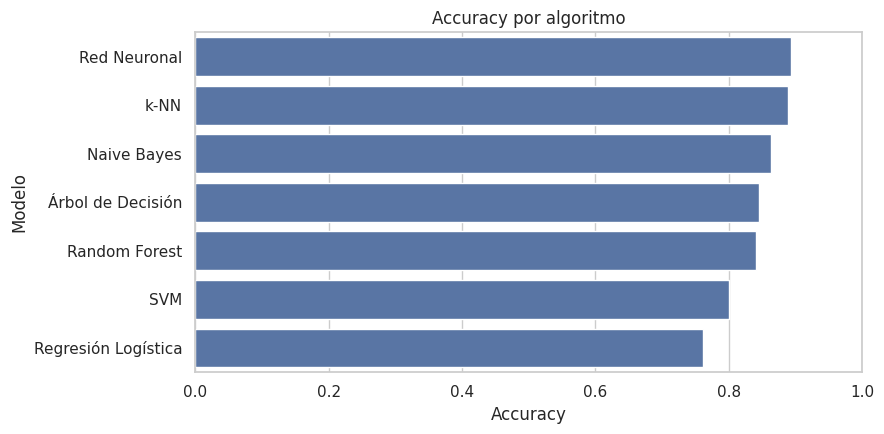

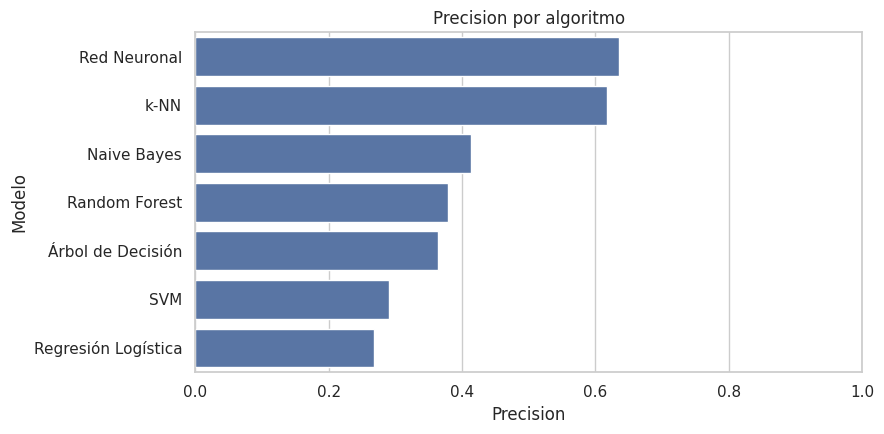

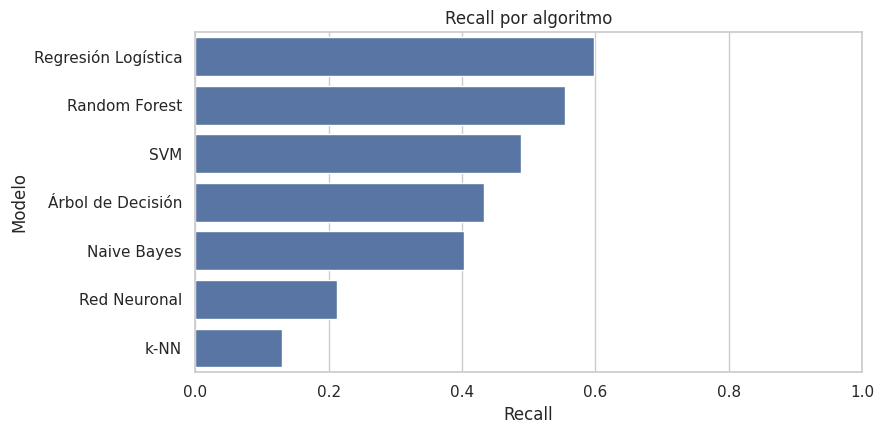

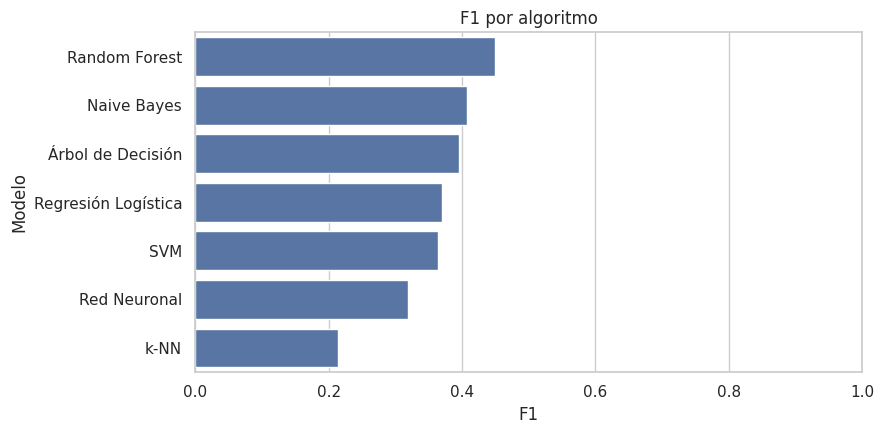

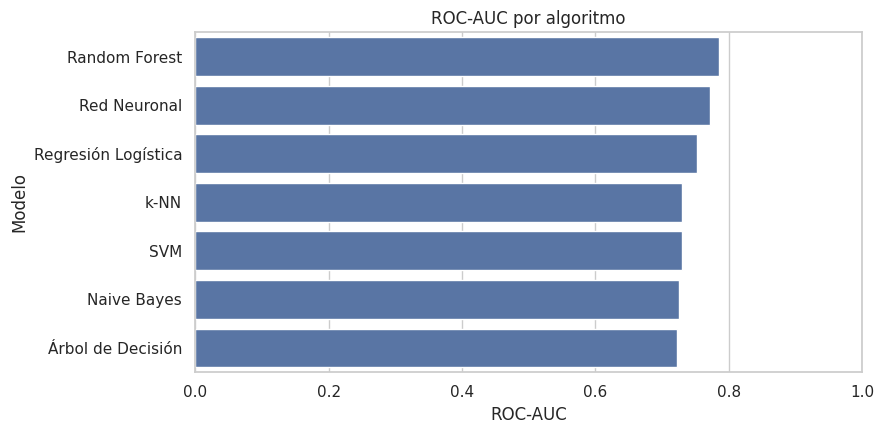

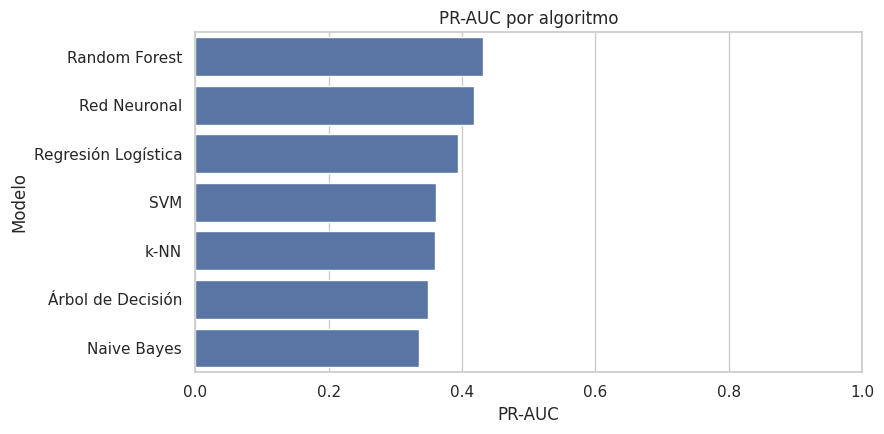

In [12]:
metricas = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

for metrica in metricas:
    plt.figure(figsize=(9, 4.5))
    tabla = resultados_df.sort_values(metrica, ascending=False)
    sns.barplot(data=tabla, x=metrica, y="Modelo")
    plt.title(f"{metrica} por algoritmo")
    plt.xlabel(metrica)
    plt.ylabel("Modelo")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

## 12. Curvas ROC

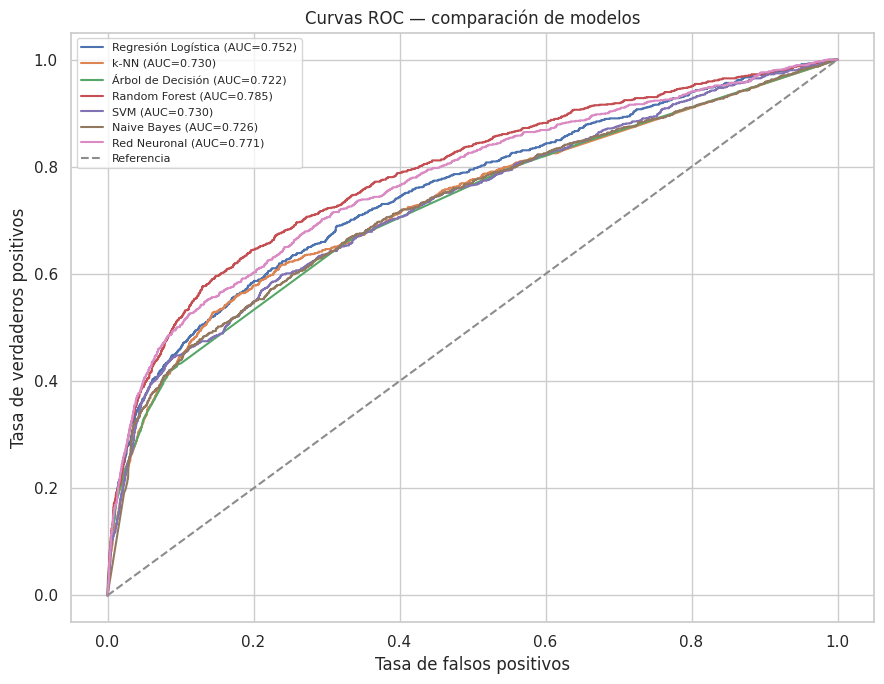

In [13]:
plt.figure(figsize=(9, 7))

for nombre in modelos:
    fpr, tpr, _ = roc_curve(y_test, scores_modelos[nombre])
    auc = roc_auc_score(y_test, scores_modelos[nombre])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Referencia")
plt.title("Curvas ROC — comparación de modelos")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 13. Curvas Precision-Recall

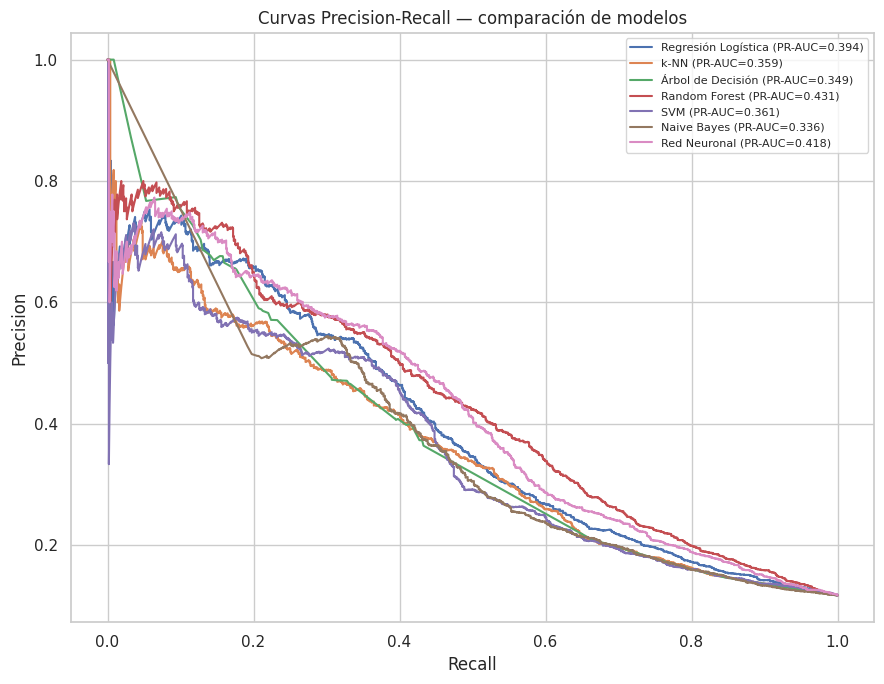

In [14]:
plt.figure(figsize=(9, 7))

for nombre in modelos:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores_modelos[nombre])
    pr_auc = average_precision_score(y_test, scores_modelos[nombre])
    plt.plot(recall_vals, precision_vals, label=f"{nombre} (PR-AUC={pr_auc:.3f})")

plt.title("Curvas Precision-Recall — comparación de modelos")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 14. Matrices de confusión

Se genera una gráfica independiente para cada modelo para facilitar la lectura.

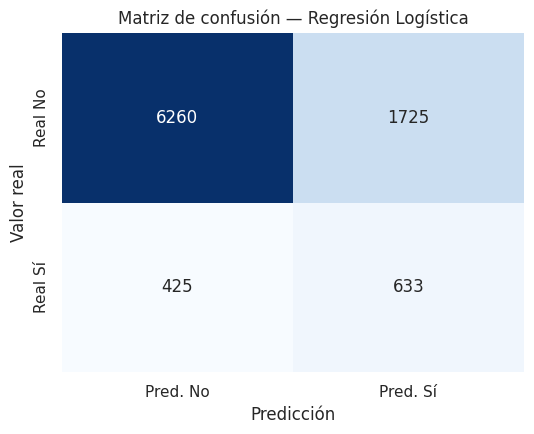

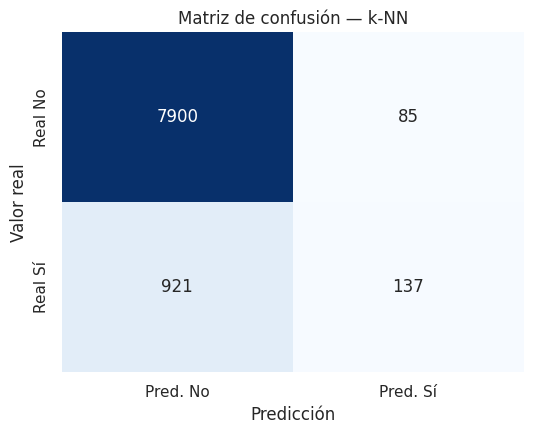

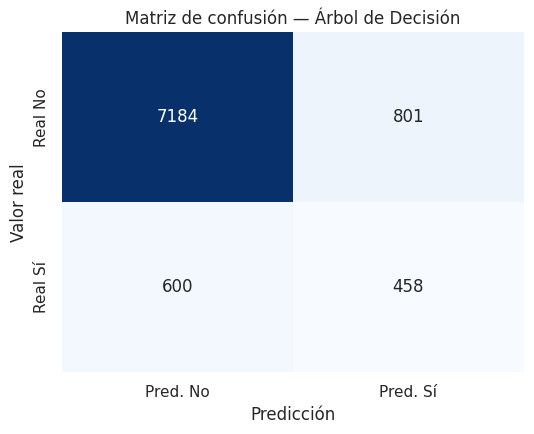

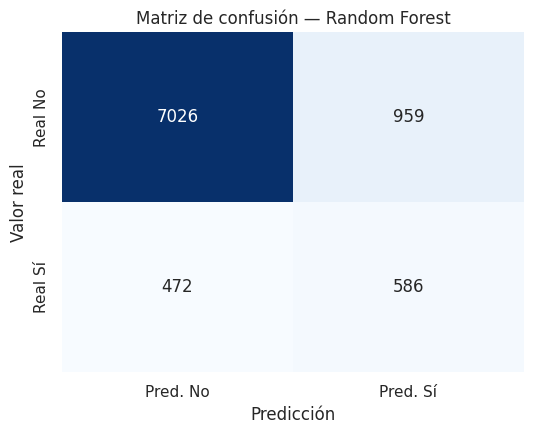

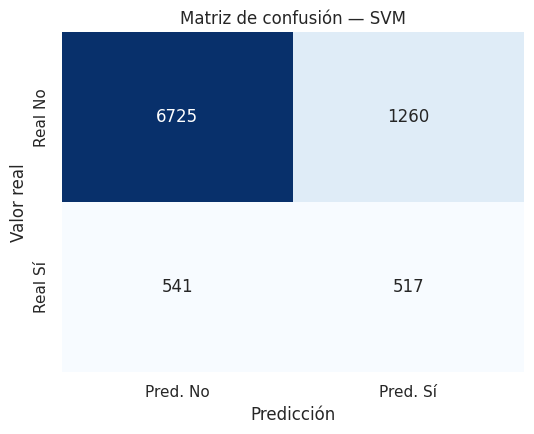

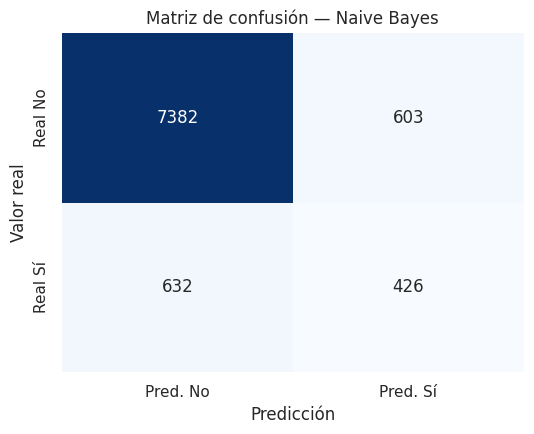

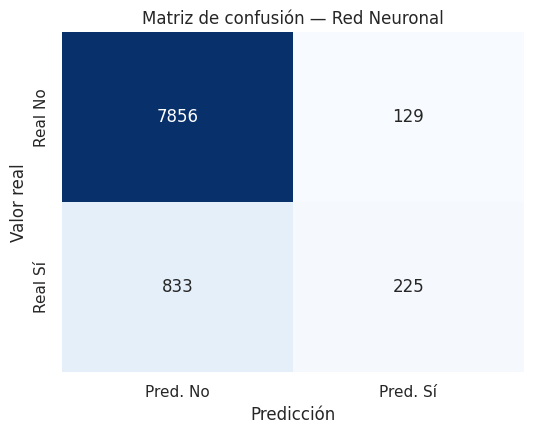

In [15]:
for nombre in modelos:
    cm = confusion_matrix(y_test, predicciones[nombre])

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Pred. No", "Pred. Sí"],
        yticklabels=["Real No", "Real Sí"]
    )
    plt.title(f"Matriz de confusión — {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.show()

## 15. Reporte de clasificación

In [16]:
for nombre in modelos:
    print("=" * 68)
    print(nombre)
    print("=" * 68)
    print(classification_report(
        y_test, predicciones[nombre],
        target_names=["No", "Sí"], digits=4, zero_division=0
    ))

Regresión Logística
              precision    recall  f1-score   support

          No     0.9364    0.7840    0.8534      7985
          Sí     0.2684    0.5983    0.3706      1058

    accuracy                         0.7622      9043
   macro avg     0.6024    0.6911    0.6120      9043
weighted avg     0.8583    0.7622    0.7970      9043

k-NN
              precision    recall  f1-score   support

          No     0.8956    0.9894    0.9401      7985
          Sí     0.6171    0.1295    0.2141      1058

    accuracy                         0.8888      9043
   macro avg     0.7564    0.5594    0.5771      9043
weighted avg     0.8630    0.8888    0.8552      9043

Árbol de Decisión
              precision    recall  f1-score   support

          No     0.9229    0.8997    0.9112      7985
          Sí     0.3638    0.4329    0.3953      1058

    accuracy                         0.8451      9043
   macro avg     0.6433    0.6663    0.6532      9043
weighted avg     0.8575    0.84

## 16. Selección del mejor modelo

Como criterio inicial se considera el mayor F1-score porque la clase positiva es minoritaria y se busca equilibrio entre Precision y Recall. La decisión final debe considerar también ROC-AUC, PR-AUC, tiempo e interpretación.

In [17]:
mejor = resultados_ordenados.iloc[0]

print("Modelo con mayor F1-score:", mejor["Modelo"])
print("Accuracy:", round(mejor["Accuracy"], 4))
print("Precision:", round(mejor["Precision"], 4))
print("Recall:", round(mejor["Recall"], 4))
print("F1:", round(mejor["F1"], 4))
print("ROC-AUC:", round(mejor["ROC-AUC"], 4))
print("PR-AUC:", round(mejor["PR-AUC"], 4))
print("Tiempo de entrenamiento (s):", round(mejor["Tiempo (s)"], 2))

Modelo con mayor F1-score: Random Forest
Accuracy: 0.8418
Precision: 0.3793
Recall: 0.5539
F1: 0.4502
ROC-AUC: 0.7854
PR-AUC: 0.4313
Tiempo de entrenamiento (s): 14.25


## 17. Análisis comparativo de resultados

La comparación se realizó con 9.043 registros de prueba. La clase positiva —clientes que aceptaron el depósito— representa aproximadamente el 11,7 % de los datos, por lo que Accuracy no basta para decidir qué modelo conviene utilizar.

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC | Tiempo (s) |
|---|---:|---:|---:|---:|---:|---:|---:|
| Random Forest | 0.8418 | 0.3793 | 0.5539 | **0.4502** | **0.7854** | **0.4313** | 14.25 |
| Naive Bayes | 0.8634 | 0.4140 | 0.4026 | 0.4082 | 0.7261 | 0.3355 | 0.03 |
| Árbol de Decisión | 0.8451 | 0.3638 | 0.4329 | 0.3953 | 0.7219 | 0.3494 | 0.26 |
| Regresión Logística | 0.7622 | 0.2684 | **0.5983** | 0.3706 | 0.7518 | 0.3935 | 0.71 |
| SVM | 0.8008 | 0.2909 | 0.4887 | 0.3647 | 0.7300 | 0.3614 | 134.00 |
| Red Neuronal | **0.8936** | **0.6356** | 0.2127 | 0.3187 | 0.7714 | 0.4184 | 5.37 |
| k-NN | 0.8888 | 0.6171 | 0.1295 | 0.2141 | 0.7302 | 0.3589 | 0.03 |

*Nota.* Los tiempos corresponden a esta ejecución y pueden variar según el entorno computacional.

### Interpretación

**Random Forest** obtuvo el F1 más alto (0,4502), además de los mayores valores de ROC-AUC (0,7854) y PR-AUC (0,4313). En este experimento es la alternativa más equilibrada entre Precision y Recall para detectar clientes que sí contratarían el depósito. Su Precision fue de 0,3793 y su Recall de 0,5539; todavía hay falsos positivos y casos positivos que el modelo no identifica, por lo que el resultado es útil como apoyo, no como decisión automática definitiva.

La **Red Neuronal** presentó la Accuracy más alta (0,8936) y también la Precision más alta (0,6356). Sin embargo, su Recall fue de 0,2127: solo recuperó una parte reducida de los clientes positivos. Lo mismo se observa en k-NN, con Accuracy de 0,8888 pero Recall de 0,1295 y F1 de 0,2141. En este dataset desbalanceado, una Accuracy elevada no significa necesariamente que el modelo sea el más útil para encontrar posibles compradores.

La **Regresión Logística** alcanzó el Recall más alto (0,5983), aunque con Precision de 0,2684. Puede ser una alternativa cuando la prioridad es no dejar pasar tantos clientes potenciales y se acepta revisar más falsos positivos. **Naive Bayes** obtuvo F1 de 0,4082 y un tiempo de entrenamiento muy bajo en esta ejecución (0,03 segundos), por lo que puede servir como referencia cuando la rapidez tiene mucho peso. El Árbol de Decisión alcanzó F1 de 0,3953. SVM tardó aproximadamente 134 segundos y su F1 fue de 0,3647, así que no ofreció la mejor relación entre tiempo y desempeño en esta prueba.

Por tanto, si el criterio principal es el equilibrio entre Precision y Recall medido con F1, se selecciona **Random Forest**. La selección cambiaría si el objetivo del negocio diera mayor prioridad a maximizar Recall, caso en el que la Regresión Logística merece considerarse. Los resultados dependen de los datos, las opciones de configuración y la división de entrenamiento/prueba utilizada; no permiten afirmar que un algoritmo será superior en todos los problemas.

### Limitaciones de la comparación

La variable objetivo está desbalanceada (88,3 % “no” frente a 11,7 % “sí”). Además, los modelos no utilizan exactamente la misma estrategia de compensación de clases: Regresión Logística, Árbol de Decisión, Random Forest y SVM incorporan ponderación de clases, mientras que k-NN, Naive Bayes y la Red Neuronal no la usan en esta configuración. Por ello, esta comparación sirve como evaluación inicial de las configuraciones seleccionadas, pero una comparación más rigurosa podría incluir validación cruzada y una búsqueda de hiperparámetros con un tratamiento uniforme del desbalance.


## 18. Conclusiones

1. Se entrenaron y evaluaron siete algoritmos de clasificación con el mismo conjunto de datos y la misma división de entrenamiento y prueba. El dataset contiene 45.211 registros; de ellos, el 88,3 % corresponde a clientes que no contrataron y el 11,7 % a clientes que sí lo hicieron.

2. Según el F1-score, Random Forest fue el modelo con mejor equilibrio entre Precision y Recall (F1 = 0,4502). También obtuvo los mayores valores de ROC-AUC (0,7854) y PR-AUC (0,4313) entre las configuraciones probadas.

3. La Red Neuronal alcanzó la Accuracy más alta (0,8936), pero su Recall para la clase positiva fue de 0,2127. Este resultado muestra por qué no conviene seleccionar un clasificador únicamente por Accuracy cuando la clase que interesa detectar es minoritaria.

4. La Regresión Logística consiguió el Recall más alto (0,5983), aunque con Precision baja (0,2684). Si el objetivo fuera identificar la mayor cantidad posible de clientes que podrían contratar, valdría la pena ajustar su umbral y comparar el costo de los falsos positivos frente al de los falsos negativos.

5. El tiempo de entrenamiento también influye en la selección. En esta ejecución, Naive Bayes y k-NN fueron los más rápidos, mientras que SVM necesitó alrededor de 134 segundos. Los tiempos pueden cambiar según el equipo y el entorno de ejecución.

6. La conclusión del ejercicio es que Random Forest es la mejor alternativa de las evaluadas cuando se usa F1 como criterio principal, pero no existe un ganador absoluto para todos los objetivos. Como continuación, sería conveniente ajustar hiperparámetros, usar validación cruzada y estudiar estrategias de balanceo para mejorar la detección de la clase positiva.


## 19. Referencias de apoyo

Universidad de Cundinamarca. (2026). *Algoritmos de Machine Learning Supervisado para Clasificación* [Material de apoyo de la asignatura Introducción a Machine Learning].

Fuchs, K. (s. f.). *Machine learning: Classification models*. Medium. https://medium.com/fuzz/machine-learning-classification-models-3040f71e2529

Naukri Code 360. (s. f.). *CART (Classification and Regression Tree)*. https://www.naukri.com/code360/library/classification-and-regression-tree-algorithm

Moro, S., Rita, P., & Cortez, P. (2014). *Bank Marketing* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306

## 20. Exportación de la tabla final


In [18]:
resultados_df.to_csv("comparacion_algoritmos_bank_marketing.csv", index=False)
print("Archivo creado: comparacion_algoritmos_bank_marketing.csv")

Archivo creado: comparacion_algoritmos_bank_marketing.csv


## 21. Enlace al repositorio

**Repositorio GitHub:** https://github.com/gabrielasuesca/Regresion_Logistica_Bank_Marketing

Antes de entregar, confirma que este notebook comparativo de la Semana 7 esté subido al repositorio enlazado. El enlace lleva al repositorio; para que la profesora pueda revisar el proyecto, el archivo `.ipynb` también debe estar visible allí.
